In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.optim as optim
import pickle
import torch.nn as nn
from nice.algorithms.connectivity_AT import *
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
import gc as gc
import warnings
warnings.filterwarnings("ignore")


c:\Users\joshu\nice\.venv\Lib\site-packages\mne\externals\tempita\__init__.py:35: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi


In [26]:
file_numbers = [1,2, 4, 8, 14, 15, 20, 23]

structure = {f'dataset_{file_number}': {
    'left_attleft': [],
    'right_attleft': [],
    'left_attright': [],
    'right_attright': []
} for file_number in file_numbers}

def smooth_with_gaussian(data, sigma=2):
    return gaussian_filter1d(data, sigma=sigma, axis=1)  # Gaussian filter along the time axis

def preprocess(data):   # This will receive (trials, time, neurons). Therefore mean across trials. 
    data_z = np.zeros_like(data)
    mean = np.mean(data, axis = 0)
    std = np.std(data, axis = 0)
   
    std[std == 0] = 1  # Avoid division by zero by setting std to 1 where it is 0
    data_z = (data - mean) / std
    return data_z

def get_data(file_number):
    file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
    data = pickle.load(open(file_path, 'rb'))

    label_left = data['label_left'][0]
    label_right = data['label_right'][0]  #for class of input
    attend_01 = data['attend'][0]
    omitted = data['omit'][0]
    trial_correct = data['trial_correct'][0]
    relevant = np.where((omitted == 0) & (trial_correct == 1))[0]

    left = data['SP'][0][0][relevant, 100:350, :]
    right = data['SP'][0][1][relevant, 100:350, :]
    att = data['SP'][0][2][relevant, 100:350, :]

    left = preprocess(left)
    right = preprocess(right)
       
    left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
    _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
    right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
    _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

    left_attleft = left[left_indices]
    right_attleft = right[left_indices]
    att_attleft = att[left_indices]

    left_attright = left[right_indices]
    right_attright = right[right_indices]
    att_attright = att[right_indices]

    return left_attleft, left_attright, right_attleft, right_attright, att_attleft, att_attright


def collect_data(file_numbers):
    l_al, l_ar, r_al, r_ar, a_al, a_ar = [], [], [], [], [], []
    for file_number in file_numbers:
        left_attleft, left_attright, right_attleft, right_attright, att_attleft, att_attright = get_data(file_number)
        l_al.append(left_attleft)
        l_ar.append(left_attright)
        r_al.append(right_attleft)
        r_ar.append(right_attright)
        a_al.append(att_attleft)
        a_ar.append(att_attright)
       
    return l_al, l_ar, r_al, r_ar, a_al, a_ar

   

In [27]:
def tensor_inputs(x_train, x_test, x_val):
     return (
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(x_test, dtype=torch.float32),
        torch.tensor(x_val, dtype=torch.float32)
    )

def tensor_targets(y_train, y_test, y_val):
    
    mean = np.mean(y_train, axis=0, keepdims=True)
    std = np.std(y_train, axis=0, keepdims=True)
    std[std == 0] = 1  # avoid division by zero
    y_train = (y_train - mean) / std
    y_test = (y_test - mean) / std
    y_val = (y_val - mean) / std

    return (
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )


In [20]:
def prep_data(x_list, y_list, batch_size=16, shuffle=True):
    x_raw = np.concatenate(x_list, axis=0) 
    print(f"Shape of x_raw: {x_raw.shape}")  # Debugging line to check shape
    y_raw = np.concatenate(y_list, axis=0)   
    print(f"Shape of y_raw: {y_raw.shape}")  # Debugging line to check shape

    #finding the output counts
    y_counts = np.sum(y_raw, axis=1) 
    print(f"Shape of y_counts: {y_counts.shape}")  # Debugging line to check shape
    x_counts = np.sum(x_raw, axis=1)  # (N, neurons)
    print(f"Shape of x_counts: {x_counts.shape}")  # Debugging line to check shape
   
    #ttv split
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        x_counts, y_counts, test_size=0.2, random_state=42, shuffle=shuffle
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=42, shuffle=shuffle
    )

    #then norm based on training data
    X_tr, X_te, X_val = tensor_inputs(X_tr, X_te, X_val)
    y_tr, y_te, y_val = tensor_targets(y_tr, y_te, y_val)

    #wrap as tensors
    def make_ds(X, y):            
        return TensorDataset(X, y)

    train_ds = make_ds(X_tr, y_tr)
    val_ds   = make_ds(X_val, y_val)
    test_ds  = make_ds(X_te,  y_te)

    #build dataloaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, drop_last=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)

    return train_loader, val_loader, test_loader

In [5]:
import torch.nn.functional as F

class SimpleAvgMLP(nn.Module):
    def __init__(self, input_dim, output_dim=250, hidden_dims=[128, 64, 32], dropout=0.3):
        super().__init__()
        
        # Create a list to hold all layers
        layers = []
        
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dims[0]))
        layers.append(nn.LeakyReLU())
        layers.append(nn.Dropout(dropout))
        
        # Hidden layers
        for i in range(len(hidden_dims)-1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
            layers.append(nn.LeakyReLU())
            layers.append(nn.Dropout(dropout))
        
        # Create sequential model for hidden layers
        self.hidden_layers = nn.Sequential(*layers)
        
        # Output layer
        self.output_layer = nn.Linear(hidden_dims[-1], output_dim)
        
    def forward(self, x):
        h = self.hidden_layers(x)  # Apply all hidden layers
        out = self.output_layer(h)      # [batch, output_dim]
        return out  # Return None for attention weights to match LSTM interface
    

In [6]:
def train(model, train_loader, val_loader,
           criterion, epochs=1000, clip_value = 1.0, 
           lr = 1e-3, wd = 1e-5, patience = 20):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5, verbose=True
    )
    loss_history = []
    validation_loss_history = []

    best_val_loss = float('inf')
    best_model_state = None
    epochs_since_improvement = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)  #gradient clipping
            optimizer.step()
            epoch_loss += loss.item()

        loss_history.append(epoch_loss / len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
           for xb_val, yb_val in val_loader:
                val_loss += criterion(model(xb_val), yb_val).item()
        val_loss_item = val_loss / len(val_loader)
        validation_loss_history.append(val_loss_item)

        scheduler.step(val_loss_item)  # Reduce learning rate if validation loss doesn't improve

        #early stopping
        if val_loss_item < best_val_loss:
            best_val_loss = val_loss_item
            best_model_state = model.state_dict()
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        if epochs_since_improvement >= patience:
            print(f"Early stopping at epoch {epoch} with validation loss: {best_val_loss:.4f}")
            break

        if epoch % 1 == 0:
            clear_output(wait=True)  #clears the Jupyter output cell
            plt.figure(figsize=(10, 7))
            plt.plot(loss_history, label = 'Training Loss')
            plt.plot(validation_loss_history, label = 'Validation Loss')
            plt.legend()
            plt.xlim(0, epochs)
            plt.ylim(0.0, 1.0)
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.title('Losses')
            plt.grid(True)
            plt.show()
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return loss_history, validation_loss_history


In [7]:
def create_model(model, n_neurons_in, output_dim, hidden_dims, dropout):
    if model == 'MLP':
        return SimpleAvgMLP(
            input_dim=n_neurons_in,
            output_dim=output_dim,
            hidden_dims=hidden_dims,
            dropout=dropout)

In [18]:
def run_model(model_type = 'MLP', output_dim = 80, 
              data_in = None, data_pred = None, batch_size = 32, criterion = nn.MSELoss(),
               epochs = 150, lr = 1e-2, wd = 1e-4, patience = 10, hidden_dims = [256, 128, 96], 
               dropout = 0.3):

    # ─── Prepare the data ─────────────────────────────────────────────────────
    train_loader, val_loader, test_loader = prep_data(
        data_in, data_pred,
        batch_size=batch_size,
        shuffle=True
    )

    # ─── Inspect input dim ────────────────────────────────────────────────────
    sample_x, _ = next(iter(train_loader))
    n_neurons_in = sample_x.shape[1]
    print('n_neurons:', n_neurons_in)

    # ─── Instantiate your model ───────────────────────────────────────────────
    model = create_model(model_type, n_neurons_in, output_dim, hidden_dims, dropout)


    # ─── Train ────────────────────────────────────────────────────────────────
    criterion = criterion
    loss_history, validation_loss_history = train(
        model,
        train_loader,
        val_loader,  
        criterion,
        epochs=epochs,
        lr=lr,
        wd=wd,
        patience=patience
    )

    # ─── Final evaluation on test set ────────────────────────────────────────
    model.eval()
    test_mse = 0.0
    all_preds, all_trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            test_mse += criterion(preds, yb).item()
            all_preds.append(preds.cpu().numpy())
            all_trues.append(yb.cpu().numpy())

    test_mse /= len(test_loader)
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Test R2: {r2_score(np.concatenate(all_trues), np.concatenate(all_preds)):.4f}")
    print(f"RMSE", np.sqrt(test_mse))


    # ─── (Optional) flatten predictions & truths into arrays ─────────────────
    preds = np.concatenate(all_preds, axis=0)  # shape (n_test, 1)
    truths   = np.concatenate(all_trues, axis=0)  # same shape
    print('y_pred shape:', preds.shape)
    print('y_true shape:', truths.shape)

    return preds, truths, test_mse, loss_history, validation_loss_history, model


In [28]:
l_al, _, r_al, _, a_al, _ = collect_data(file_numbers)


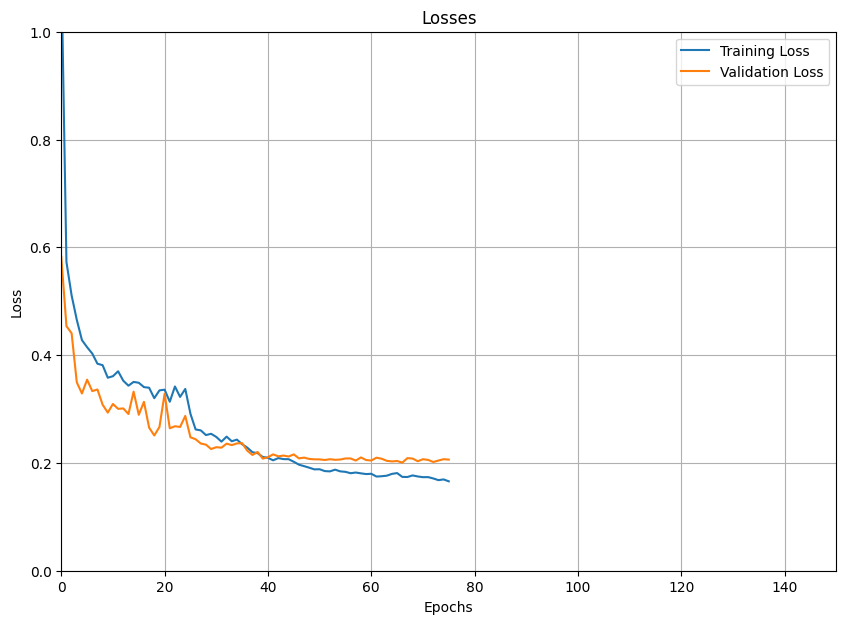

Early stopping at epoch 76 with validation loss: 0.2006
Test MSE: 0.1637
Test R2: 0.7769
RMSE 0.40456513551839424
y_pred shape: (262, 80)
y_true shape: (262, 80)
MSE for left attention left: [0.1602230038907793, 0.1616042438480589, 0.1636729488770167]
RMSE for left attention left: [np.float64(0.4002786578007617), np.float64(0.4020003032934912), np.float64(0.40456513551839424)]
R2 for left attention left: [0.7811458706855774, 0.7804368734359741, 0.7769423723220825]


In [29]:
mse_l_al = []
rmse_l_al = []
r2_l_al = []

for i in range(0, 3):   
    preds_l_al, truths_l_al, test_mse_l_al, _, _, _ = run_model(
        model_type= 'MLP', output_dim = 80,
        data_in = l_al, data_pred = a_al,
        batch_size=32, criterion = nn.MSELoss(),
        epochs=150,
        lr=1e-3,
        wd=1e-4,
        hidden_dims = [900, 800, 600],
        patience=10,
        dropout=0.3
    )

    mse_l_al.append(test_mse_l_al)
    rmse_l_al.append(np.sqrt(test_mse_l_al))
    r2_l_al.append(r2_score(truths_l_al, preds_l_al))

    del preds_l_al, truths_l_al, test_mse_l_al
    gc.collect()


print('MSE for left attention left:', mse_l_al)
print('RMSE for left attention left:', rmse_l_al)
print('R2 for left attention left:', r2_l_al)


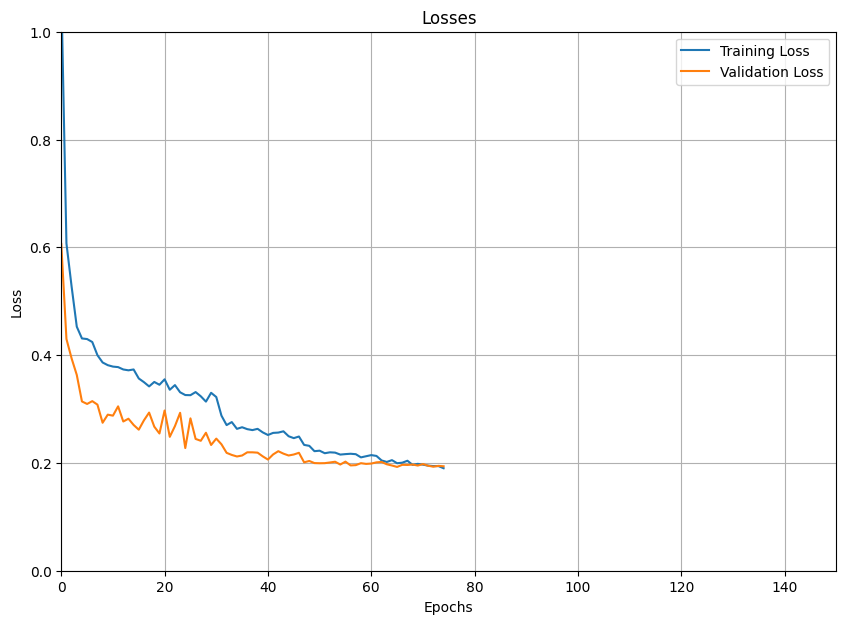

Early stopping at epoch 75 with validation loss: 0.1926
Test MSE: 0.1873
Test R2: 0.7531
RMSE 0.43273091884338677
y_pred shape: (262, 80)
y_true shape: (262, 80)
finished iteration  2
MSE for right attention left: [0.1839711152844959, 0.18458472192287445, 0.18725604812304178]
RMSE for right attention left: [np.float64(0.42891854154897047), np.float64(0.4296332411753942), np.float64(0.43273091884338677)]
R2 for right attention left: [0.7507647275924683, 0.7513352632522583, 0.7531261444091797]
average MSE for right attention left: 0.18527062844347073 ± 0.0017465814480540655
average RMSE for right attention left: 0.4304275671892505 ± 0.0020265168444801654
average R2 for right attention left: 0.7517420450846354 ± 0.0012321428244834055


In [30]:
mse_r_al = []
rmse_r_al = []
r2_r_al = []

for i in range(0, 3):
    preds_r_al, truths_r_al, test_mse_r_al, _, _, _= run_model(    
        model_type= 'MLP', output_dim = 80,
        data_in = r_al, data_pred = a_al,
        batch_size=32, criterion = nn.MSELoss(),
        epochs=150,
        lr=1e-3,
        wd=1e-4,
        hidden_dims = [900, 800, 600],
        patience=10
    )

    mse_r_al.append(test_mse_r_al)
    rmse_r_al.append(np.sqrt(test_mse_r_al))
    r2_r_al.append(r2_score(truths_r_al, preds_r_al))

    del preds_r_al, truths_r_al, test_mse_r_al
    gc.collect()

    print('finished iteration ', i)


print('MSE for right attention left:', mse_r_al)
print('RMSE for right attention left:', rmse_r_al)
print('R2 for right attention left:', r2_r_al)


avg_mse_r_al = np.mean(mse_r_al) 
avg_remse_r_al = np.mean(rmse_r_al)
avg_r2_r_al = np.mean(r2_r_al)
std_mse_r_al = np.std(mse_r_al, ddof = 1)
std_remse_r_al = np.std(rmse_r_al, ddof = 1)
std_r2_r_al = np.std(r2_r_al, ddof = 1)


print('average MSE for right attention left:', avg_mse_r_al, '±', std_mse_r_al)
print('average RMSE for right attention left:', avg_remse_r_al, '±', std_remse_r_al)
print('average R2 for right attention left:', avg_r2_r_al, '±', std_r2_r_al)

In [33]:
del l_al, r_al, a_al
gc.collect()
_, l_ar, _, r_ar, _, a_ar = collect_data(file_numbers)

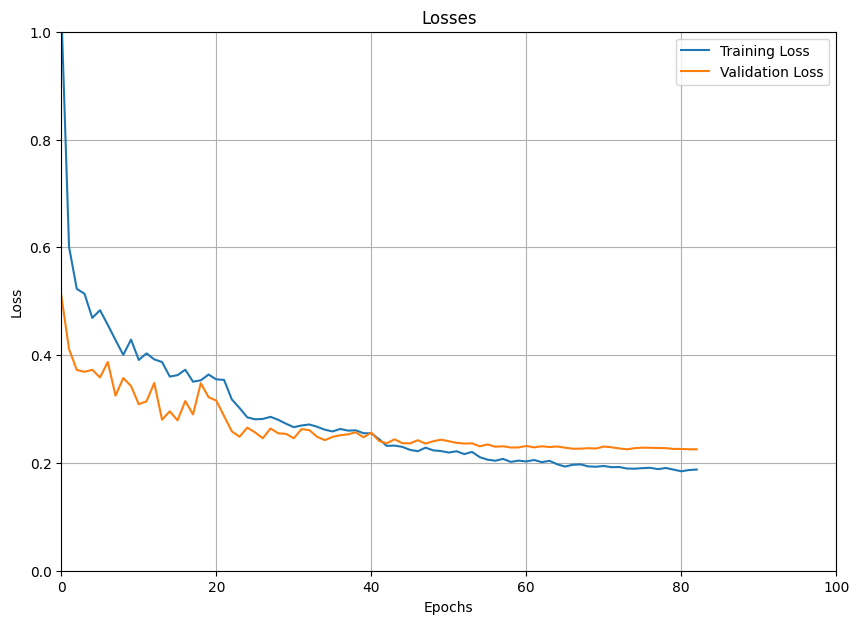

Early stopping at epoch 83 with validation loss: 0.2253
Test MSE: 0.2266
Test R2: 0.7608
RMSE 0.4759997500350841
y_pred shape: (269, 80)
y_true shape: (269, 80)
finished iteration  2
MSE for left attention right: [0.22854295704099867, 0.23175036741627586, 0.22657576203346252]
RMSE for left attention right: [np.float64(0.4780616665671895), np.float64(0.4814045776852105), np.float64(0.4759997500350841)]
R2 for left attention right: [0.7597666382789612, 0.7562113404273987, 0.7608081698417664]
average MSE for left attention right: 0.22895636216357904 ± 0.0026119557927905177
average RMSE for left attention right: 0.4784886647624947 ± 0.002727597124941315
average R2 for left attention right: 0.7589287161827087 ± 0.0024102479635381984


In [34]:
mse_l_ar = []
rmse_l_ar = []
r2_l_ar = []

for i in range(0, 3):
    preds_l_ar, truths_l_ar, test_mse_l_ar, _, _, _ = run_model(
        model_type= 'MLP', output_dim = 80,
        data_in = l_ar, data_pred = a_ar,
        batch_size=32, criterion = nn.MSELoss(),
        epochs=100,
        lr=1e-3,
        wd=1e-4,
        hidden_dims = [900, 800, 600],
        patience=10
    )

    mse_l_ar.append(test_mse_l_ar)
    rmse_l_ar.append(np.sqrt(test_mse_l_ar))
    r2_l_ar.append(r2_score(truths_l_ar, preds_l_ar))

    del preds_l_ar, truths_l_ar, test_mse_l_ar
    gc.collect()

    print('finished iteration ', i)

print('MSE for left attention right:', mse_l_ar)
print('RMSE for left attention right:', rmse_l_ar)
print('R2 for left attention right:', r2_l_ar)


avg_mse_l_ar = np.mean(mse_l_ar) 
avg_remse_l_ar = np.mean(rmse_l_ar) 
avg_r2_l_ar = np.mean(r2_l_ar) 
std_mse_l_ar = np.std(mse_l_ar, ddof = 1)
std_remse_l_ar = np.std(rmse_l_ar, ddof = 1)
std_r2_l_ar = np.std(r2_l_ar, ddof = 1)

print('average MSE for left attention right:', avg_mse_l_ar, '±', std_mse_l_ar)
print('average RMSE for left attention right:', avg_remse_l_ar, '±', std_remse_l_ar)
print('average R2 for left attention right:', avg_r2_l_ar, '±', std_r2_l_ar)



In [35]:
print('mse_l_ar', mse_l_ar)
print('rmse_l_ar', rmse_l_ar)
print('r2_l_ar', r2_l_ar)

print('std_mse_l_ar', std_mse_l_ar)
print('std_rmse_l_ar', std_remse_l_ar)
print('std_r2_l_ar', std_r2_l_ar)

mse_l_ar [0.22854295704099867, 0.23175036741627586, 0.22657576203346252]
rmse_l_ar [np.float64(0.4780616665671895), np.float64(0.4814045776852105), np.float64(0.4759997500350841)]
r2_l_ar [0.7597666382789612, 0.7562113404273987, 0.7608081698417664]
std_mse_l_ar 0.0026119557927905177
std_rmse_l_ar 0.002727597124941315
std_r2_l_ar 0.0024102479635381984


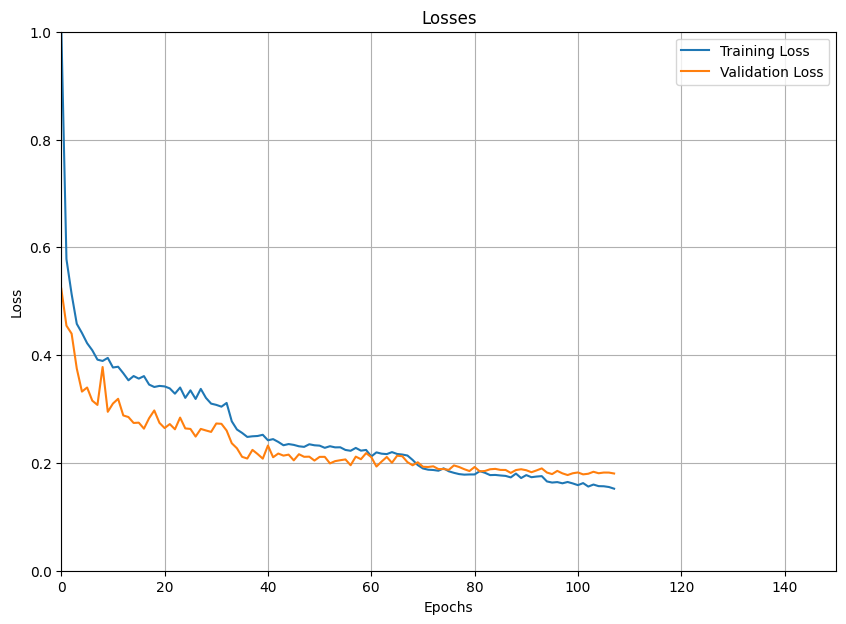

Early stopping at epoch 108 with validation loss: 0.1775
Test MSE: 0.1900
Test R2: 0.7996
RMSE 0.4358530037867789
y_pred shape: (269, 80)
y_true shape: (269, 80)
finished iteration  2
MSE for right attention right: [0.19800485173861185, 0.19331632720099556, 0.18996784090995789]
RMSE for right attention right: [np.float64(0.4449773609281846), np.float64(0.43967752637699775), np.float64(0.4358530037867789)]
R2 for right attention right: [0.7923981547355652, 0.7963379621505737, 0.799625039100647]
average MSE for right attention right: 0.19376300661652177 ± 0.004037081574623727
average RMSE for right attention right: 0.4401692970306537 ± 0.004582013977808033
average R2 for right attention right: 0.7961203853289286 ± 0.0036183517188844126


In [36]:
mse_r_ar = []
rmse_r_ar = []
r2_r_ar = []

for i in range(0, 3):
    preds_r_ar, truths_r_ar, test_mse_r_ar, _, _, _ = run_model(
        model_type= 'MLP', output_dim = 80,
        data_in = r_ar, data_pred = a_ar,
        batch_size=32, criterion = nn.MSELoss(),
        epochs=150,
        lr=1e-3,
        wd=1e-4,
        hidden_dims = [900, 800, 600],
        patience=10
    )

    mse_r_ar.append(test_mse_r_ar)
    rmse_r_ar.append(np.sqrt(test_mse_r_ar))
    r2_r_ar.append(r2_score(truths_r_ar, preds_r_ar))

    del preds_r_ar, truths_r_ar, test_mse_r_ar
    gc.collect()

    print('finished iteration ', i)

print('MSE for right attention right:', mse_r_ar)
print('RMSE for right attention right:', rmse_r_ar)
print('R2 for right attention right:', r2_r_ar)


avg_mse_r_ar = np.mean(mse_r_ar) 
avg_remse_r_ar = np.mean(rmse_r_ar) 
avg_r2_r_ar = np.mean(r2_r_ar) 
std_mse_r_ar = np.std(mse_r_ar, ddof = 1)
std_remse_r_ar = np.std(rmse_r_ar, ddof = 1)
std_r2_r_ar = np.std(r2_r_ar, ddof = 1)

print('average MSE for right attention right:', avg_mse_r_ar, '±', std_mse_r_ar)
print('average RMSE for right attention right:', avg_remse_r_ar, '±', std_remse_r_ar)
print('average R2 for right attention right:', avg_r2_r_ar, '±', std_r2_r_ar)

In [39]:
from scipy.stats import ttest_rel, wilcoxon
import numpy as np

in_rmse = 0.5 * (np.array(rmse_l_al) + np.array(rmse_r_ar))
out_rmse = 0.5 * (np.array(rmse_l_ar) + np.array(rmse_r_al))

#ttest 
t_stat, p_value = ttest_rel(in_rmse, out_rmse)
print(f"T-test: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")





T-test: t-statistic = -27.8111, p-value = 0.0013
